In [1]:
# CELL 1: Imports et chargement des données

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/weatherAUS.csv')
print(f"Dataset chargé: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

Dataset chargé: 145,460 lignes × 23 colonnes


Pourcentage de valeurs manquantes par colonne (%):
Sunshine         48.01
Evaporation      43.17
Cloud3pm         40.81
Cloud9am         38.42
Pressure9am      10.36
Pressure3pm      10.33
WindDir9am        7.26
WindGustDir       7.10
WindGustSpeed     7.06
Humidity3pm       3.10
WindDir3pm        2.91
Temp3pm           2.48
RainTomorrow      2.25
Rainfall          2.24
RainToday         2.24
WindSpeed3pm      2.11
Humidity9am       1.82
WindSpeed9am      1.21
Temp9am           1.21
MinTemp           1.02
MaxTemp           0.87
Date              0.00
Location          0.00



Figure sauvegardée: figures/etape2_01_valeurs_manquantes.png


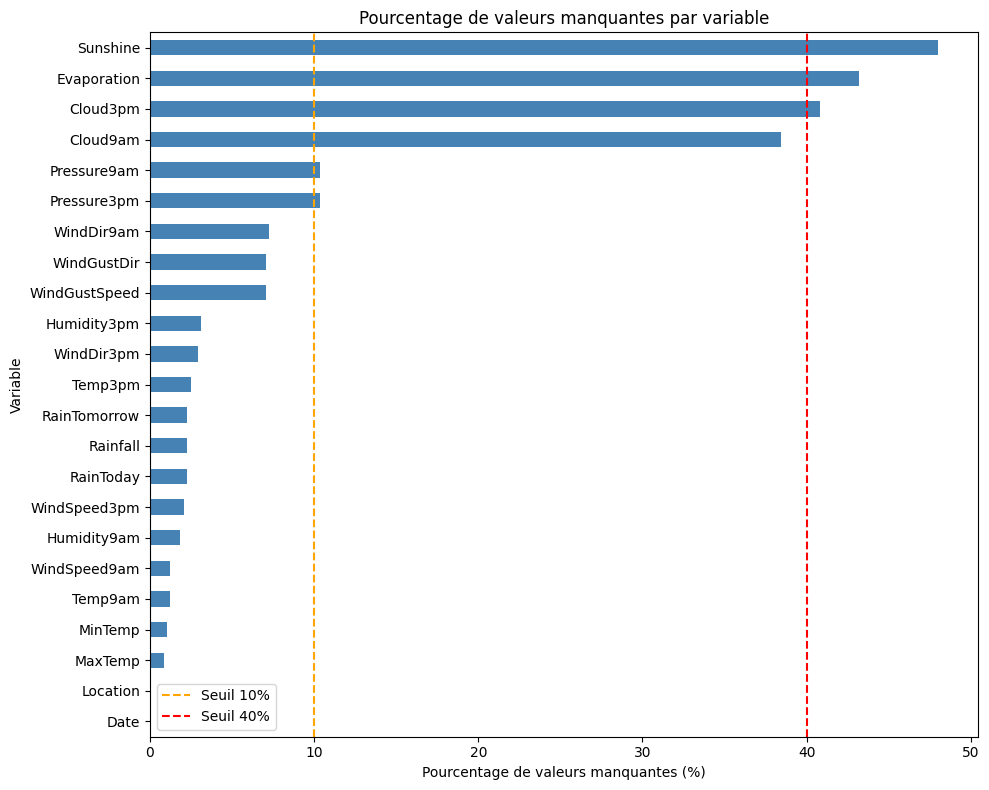

In [2]:
# CELL 2: Etat des lieux des valeurs manquantes

import os

# Pourcentage de valeurs manquantes par colonne, trié décroissant
pct_manquant = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

print("Pourcentage de valeurs manquantes par colonne (%):")
print(pct_manquant.round(2).to_string())

# Graphique en barres horizontales (trié pour lecture, plus grand en haut)
pct_plot = pct_manquant.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
pct_plot.plot(kind='barh', color='steelblue', ax=ax)
ax.axvline(x=10, color='orange', linestyle='--', linewidth=1.5, label='Seuil 10%')
ax.axvline(x=40, color='red', linestyle='--', linewidth=1.5, label='Seuil 40%')
ax.set_title("Pourcentage de valeurs manquantes par variable")
ax.set_xlabel("Pourcentage de valeurs manquantes (%)")
ax.set_ylabel("Variable")
ax.legend()
plt.tight_layout()

# Création du dossier figures/ à la racine du projet si nécessaire
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/etape2_01_valeurs_manquantes.png', dpi=100, bbox_inches='tight')
print("\nFigure sauvegardée: figures/etape2_01_valeurs_manquantes.png")

plt.show()

In [3]:
# CELL 3: Suppression des variables tres lacunaires (Sunshine, Evaporation, Cloud3pm, Cloud9am)

# Decision issue de la mesure en CELL 2 : ces 4 colonnes depassent le seuil de 40% de valeurs manquantes
print(f"Avant suppression des colonnes: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

colonnes_a_supprimer = ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']
df = df.drop(columns=colonnes_a_supprimer)

print(f"Apres suppression des colonnes: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Colonnes supprimees: {colonnes_a_supprimer}")

Avant suppression des colonnes: 145,460 lignes × 23 colonnes
Apres suppression des colonnes: 145,460 lignes × 19 colonnes
Colonnes supprimees: ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']


In [4]:
# CELL 4: Suppression des lignes sans variable cible (RainTomorrow manquante)

# La cible RainTomorrow ne peut pas etre imputee : on retire les lignes ou elle est manquante
nb_lignes_avant = df.shape[0]
nb_cible_nan = df['RainTomorrow'].isnull().sum()
print(f"Nombre de lignes avant: {nb_lignes_avant:,}")
print(f"Nombre de RainTomorrow manquants: {nb_cible_nan:,}")

df = df.dropna(subset=['RainTomorrow'])

print(f"Apres suppression des lignes sans cible: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Nombre de lignes supprimees: {nb_lignes_avant - df.shape[0]:,}")

Nombre de lignes avant: 145,460
Nombre de RainTomorrow manquants: 3,267


Apres suppression des lignes sans cible: 142,193 lignes × 19 colonnes
Nombre de lignes supprimees: 3,267


In [5]:
# CELL 5: Decoupage train/test (stratifie sur la cible)

from sklearn.model_selection import train_test_split

# Separation des variables explicatives (X) et de la cible (y)
y = df['RainTomorrow']
X = df.drop(columns=['RainTomorrow'])

# Decoupage 80/20, stratifie sur y pour conserver la proportion de classes, reproductible (random_state=42)
# Le split est fait AVANT toute transformation ajustee (imputation, scaling) pour eviter la fuite de donnees
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Preuve du decoupage : dimensions des jeux
print(f"X_train: {X_train.shape[0]:,} lignes × {X_train.shape[1]} colonnes")
print(f"X_test:  {X_test.shape[0]:,} lignes × {X_test.shape[1]} colonnes")

# Preuve de la stratification : proportions de classes conservees dans les deux jeux
print("\nProportions des classes dans y_train:")
print((y_train.value_counts(normalize=True) * 100).round(2).to_string())
print("\nProportions des classes dans y_test:")
print((y_test.value_counts(normalize=True) * 100).round(2).to_string())

X_train: 113,754 lignes × 18 colonnes
X_test:  28,439 lignes × 18 colonnes

Proportions des classes dans y_train:
RainTomorrow
No     77.58
Yes    22.42

Proportions des classes dans y_test:
RainTomorrow
No     77.58
Yes    22.42


Figure sauvegardee: figures/etape2_02_stratification_train_test.png


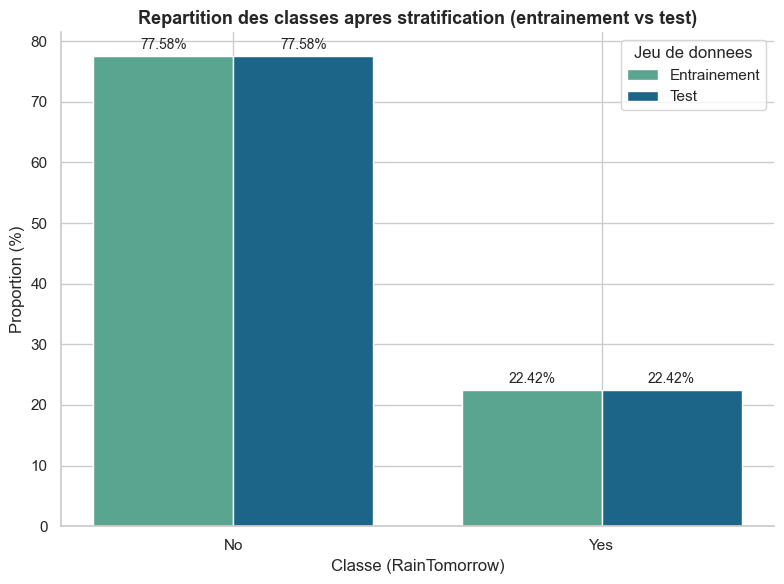

In [6]:
# CELL 6: Verification visuelle de la stratification (train vs test)

import seaborn as sns

# Proportions de classes (en %) deja calculees en CELL 5, reprises pour les deux jeux
prop_train = y_train.value_counts(normalize=True) * 100
prop_test = y_test.value_counts(normalize=True) * 100

classes = ['No', 'Yes']
valeurs_train = [prop_train[c] for c in classes]
valeurs_test = [prop_test[c] for c in classes]

# Style
sns.set_theme(style="whitegrid", context="notebook")
couleurs = [sns.color_palette("crest")[1], sns.color_palette("crest")[4]]

# Barres groupees : deux barres (Entrainement, Test) par classe
x = np.arange(len(classes))
largeur = 0.38

fig, ax = plt.subplots(figsize=(8, 6))
barres_train = ax.bar(x - largeur / 2, valeurs_train, largeur, label='Entrainement', color=couleurs[0])
barres_test = ax.bar(x + largeur / 2, valeurs_test, largeur, label='Test', color=couleurs[1])

# Annotation des valeurs sur les barres
for barres in (barres_train, barres_test):
    for b in barres:
        ax.annotate(f"{b.get_height():.2f}%",
                    xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=10)

ax.set_title("Repartition des classes apres stratification (entrainement vs test)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Classe (RainTomorrow)")
ax.set_ylabel("Proportion (%)")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend(title="Jeu de donnees")
sns.despine()
plt.tight_layout()
fig.savefig('../figures/etape2_02_stratification_train_test.png', dpi=150, bbox_inches='tight')
print("Figure sauvegardee: figures/etape2_02_stratification_train_test.png")
plt.show()

In [7]:
# CELL 7: Detection des valeurs aberrantes par la methode IQR (sur X_train)

# Mesure faite sur X_train uniquement (pas de fuite depuis le test), colonnes numeriques
X_train_num = X_train.select_dtypes(include=[np.number])

resultats_iqr = []
for col in X_train_num.columns:
    Q1 = X_train_num[col].quantile(0.25)
    Q3 = X_train_num[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    # Une valeur manquante n'est pas comptee comme aberrante (comparaison -> False)
    masque_outliers = (X_train_num[col] < borne_inf) | (X_train_num[col] > borne_sup)
    nb_outliers = int(masque_outliers.sum())
    # Pourcentage rapporte aux valeurs non manquantes de la variable
    nb_non_nuls = X_train_num[col].notna().sum()
    pct_outliers = nb_outliers / nb_non_nuls * 100
    resultats_iqr.append({
        'Variable': col, 'Q1': Q1, 'Q3': Q3,
        'borne_inf': borne_inf, 'borne_sup': borne_sup,
        'nb_outliers': nb_outliers, 'pct_outliers': pct_outliers
    })

table_iqr = pd.DataFrame(resultats_iqr).sort_values('pct_outliers', ascending=False).reset_index(drop=True)

# Arrondi pour la lisibilite de l'affichage
for c in ['Q1', 'Q3', 'borne_inf', 'borne_sup', 'pct_outliers']:
    table_iqr[c] = table_iqr[c].round(2)

print("Detection des valeurs aberrantes (methode IQR, X_train):")
print(table_iqr.to_string(index=False))

Detection des valeurs aberrantes (methode IQR, X_train):
     Variable     Q1     Q3  borne_inf  borne_sup  nb_outliers  pct_outliers
     Rainfall    0.0    0.6      -0.90       1.50        22826         20.27
WindGustSpeed   31.0   48.0       5.50      73.50         2390          2.25
 WindSpeed3pm   13.0   24.0      -3.50      40.50         1950          1.75
 WindSpeed9am    7.0   19.0     -11.00      37.00         1348          1.20
  Humidity9am   57.0   83.0      18.00     122.00         1149          1.02
  Pressure9am 1013.0 1022.4     998.90    1036.50         1035          1.01
  Pressure3pm 1010.5 1020.0     996.25    1034.25          801          0.78
      Temp3pm   16.6   26.4       1.90      41.10          595          0.53
      MaxTemp   17.9   28.2       2.45      43.65          383          0.34
      Temp9am   12.3   21.6      -1.65      35.55          203          0.18
      MinTemp    7.6   16.8      -6.20      30.60           48          0.04
  Humidity3pm   37.

Figure sauvegardee: figures/etape2_03_outliers_iqr.png


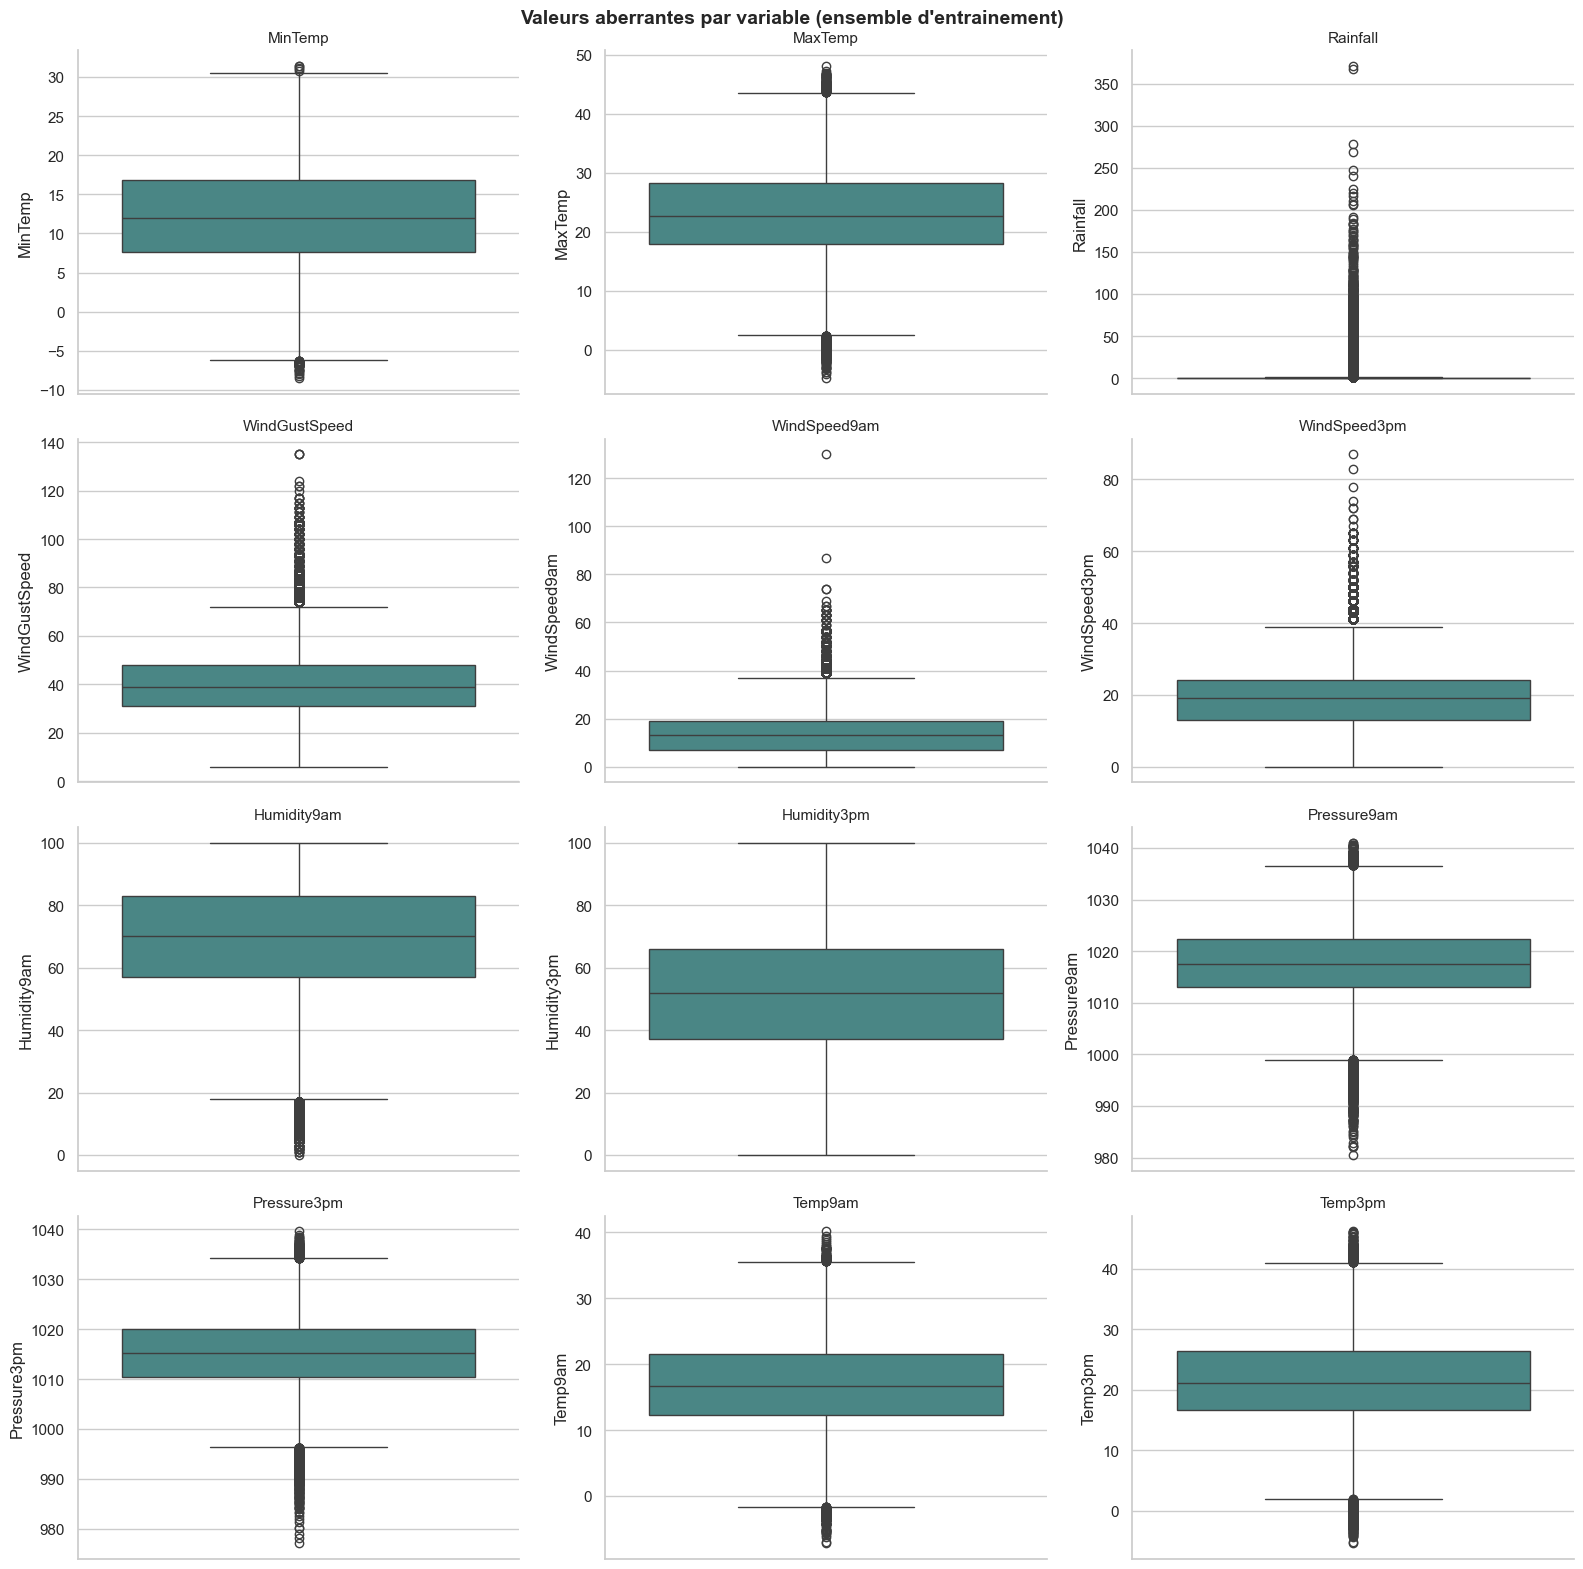

In [8]:
# CELL 8: Visualisation des valeurs aberrantes (boxplots, X_train)

import seaborn as sns

# Style
sns.set_theme(style="whitegrid", context="notebook")
couleur = sns.color_palette("crest")[2]

# Un sous-graphique par variable : chaque variable garde sa propre echelle
# (les echelles sont tres differentes : pression ~1000, humidite ~50, rainfall asymetrique)
colonnes_num = X_train_num.columns
n = len(colonnes_num)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.ravel()

for i, col in enumerate(colonnes_num):
    sns.boxplot(y=X_train_num[col], color=couleur, ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel(col)

# Masquer les sous-graphiques vides eventuels
for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Valeurs aberrantes par variable (ensemble d'entrainement)",
             fontsize=14, fontweight='bold')
sns.despine()
plt.tight_layout()
fig.savefig('../figures/etape2_03_outliers_iqr.png', dpi=150, bbox_inches='tight')
print("Figure sauvegardee: figures/etape2_03_outliers_iqr.png")
plt.show()

In [9]:
# CELL 9: Mesure de l'asymetrie des variables numeriques (X_train)

# Mesure sur X_train uniquement (regle anti-fuite), colonnes numeriques
X_train_num = X_train.select_dtypes(include=[np.number])

resultats_skew = []
for col in X_train_num.columns:
    skew = X_train_num[col].skew()
    # Regle de la formation : mediane si distribution asymetrique (|skew| >= 0.5), sinon moyenne
    regle = 'mediane' if abs(skew) >= 0.5 else 'moyenne'
    nb_manquants = int(X_train[col].isnull().sum())
    resultats_skew.append({
        'Variable': col,
        'skewness': round(skew, 3),
        'regle_imputation': regle,
        'nb_manquants': nb_manquants
    })

table_skew = pd.DataFrame(resultats_skew)
# Tri par asymetrie absolue decroissante
table_skew = table_skew.reindex(
    table_skew['skewness'].abs().sort_values(ascending=False).index
).reset_index(drop=True)

print("Asymetrie (skewness) des variables numeriques (X_train):")
print(table_skew.to_string(index=False))

Asymetrie (skewness) des variables numeriques (X_train):
     Variable  skewness regle_imputation  nb_manquants
     Rainfall    10.090          mediane          1131
WindGustSpeed     0.876          mediane          7440
 WindSpeed9am     0.765          mediane          1082
 WindSpeed3pm     0.625          mediane          2130
  Humidity9am    -0.487          moyenne          1418
      Temp3pm     0.237          moyenne          2203
      MaxTemp     0.222          moyenne           258
  Pressure9am    -0.098          moyenne         11287
      Temp9am     0.092          moyenne           735
  Pressure3pm    -0.049          moyenne         11262
  Humidity3pm     0.034          moyenne          2897
      MinTemp     0.024          moyenne           513


Figure sauvegardee: figures/etape2_04_distributions_numeriques.png


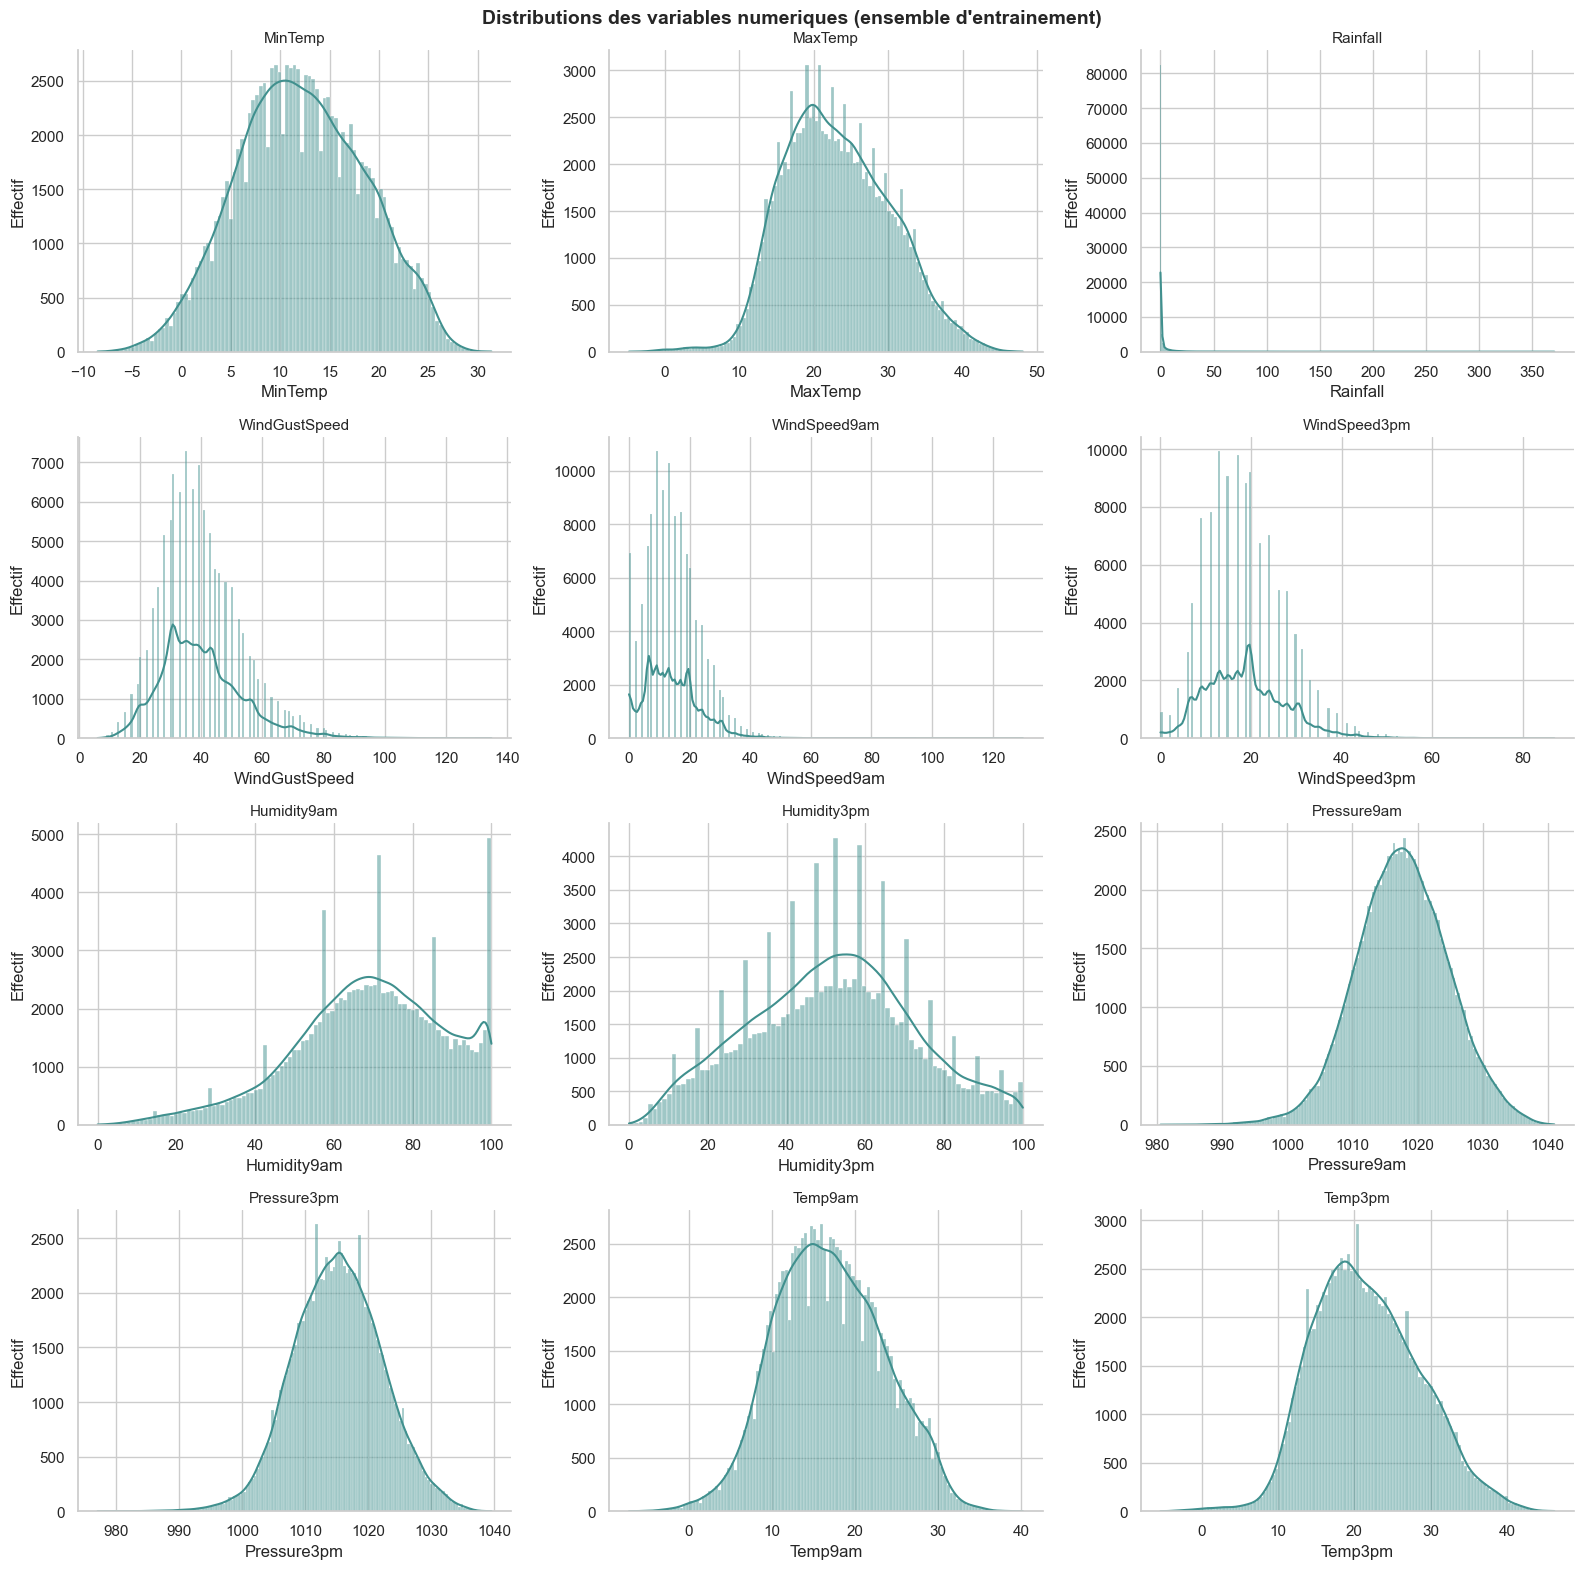

In [10]:
# CELL 10: Visualisation des distributions numeriques (X_train)

import seaborn as sns

# Style
sns.set_theme(style="whitegrid", context="notebook")
couleur = sns.color_palette("crest")[2]

# Un sous-graphique par variable : chaque variable garde sa propre echelle
colonnes_num = X_train_num.columns
n = len(colonnes_num)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.ravel()

for i, col in enumerate(colonnes_num):
    sns.histplot(X_train[col].dropna(), kde=True, color=couleur, ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Effectif")

# Masquer les sous-graphiques vides eventuels
for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distributions des variables numeriques (ensemble d'entrainement)",
             fontsize=14, fontweight='bold')
sns.despine()
plt.tight_layout()
fig.savefig('../figures/etape2_04_distributions_numeriques.png', dpi=150, bbox_inches='tight')
print("Figure sauvegardee: figures/etape2_04_distributions_numeriques.png")
plt.show()

In [13]:
# CELL 11: Imputation des valeurs manquantes (statistiques calculees sur X_train uniquement)

# Principe anti-fuite : chaque statistique est calculee UNE seule fois sur X_train,
# stockee, puis appliquee a X_train ET X_test. Jamais de recalcul sur X_test.
impute_values = {}

# Imputation par la mediane (variables asymetriques, mesure en CELL 9)
cols_mediane = ['Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am']
for col in cols_mediane:
    impute_values[col] = X_train[col].median()

# Imputation par la moyenne (variables quasi-symetriques)
cols_moyenne = ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm', 'Humidity3pm', 'Pressure9am', 'Pressure3pm']
for col in cols_moyenne:
    impute_values[col] = X_train[col].mean()

# Imputation par le mode (variables categorielles)
cols_mode = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
for col in cols_mode:
    impute_values[col] = X_train[col].mode()[0]

# Application des MEMES valeurs stockees a X_train et a X_test
for col, valeur in impute_values.items():
    X_train[col] = X_train[col].fillna(valeur)
    X_test[col] = X_test[col].fillna(valeur)

# Verification : valeurs manquantes restantes par colonne (doit etre 0 partout)
print("Valeurs manquantes restantes dans X_train:")
print(X_train.isnull().sum().to_string())
print("\nValeurs manquantes restantes dans X_test:")
print(X_test.isnull().sum().to_string())

Valeurs manquantes restantes dans X_train:
Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0

Valeurs manquantes restantes dans X_test:
Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0


In [14]:
# CELL 12: Recapitulatif des valeurs d'imputation utilisees (calculees sur X_train)

# Reutilisation des valeurs deja calculees et stockees en CELL 11 (aucun recalcul)
methode_par_col = {}
for col in cols_mediane:
    methode_par_col[col] = 'Mediane'
for col in cols_moyenne:
    methode_par_col[col] = 'Moyenne'
for col in cols_mode:
    methode_par_col[col] = 'Mode'

lignes = []
for col, valeur in impute_values.items():
    # Arrondi a 1 decimale pour les valeurs numeriques, categorie conservee pour le mode
    val_affichee = round(valeur, 1) if isinstance(valeur, (int, float, np.floating)) else valeur
    lignes.append({
        'Variable': col,
        'Methode': methode_par_col[col],
        'Valeur_imputation': val_affichee
    })

table_imputation = pd.DataFrame(lignes)
print("Valeurs d'imputation utilisees (calculees sur X_train):")
print(table_imputation.to_string(index=False))

# Confirmation des dimensions des deux jeux
print(f"\nTotal lignes X_train: {X_train.shape[0]:,}")
print(f"Total lignes X_test:  {X_test.shape[0]:,}")

Valeurs d'imputation utilisees (calculees sur X_train):
     Variable Methode Valeur_imputation
     Rainfall Mediane               0.0
WindGustSpeed Mediane              39.0
 WindSpeed9am Mediane              13.0
 WindSpeed3pm Mediane              19.0
  Humidity9am Mediane              70.0
      MinTemp Moyenne              12.2
      MaxTemp Moyenne              23.2
      Temp9am Moyenne              17.0
      Temp3pm Moyenne              21.7
  Humidity3pm Moyenne              51.5
  Pressure9am Moyenne            1017.7
  Pressure3pm Moyenne            1015.3
  WindGustDir    Mode                 W
   WindDir9am    Mode                 N
   WindDir3pm    Mode                SE
    RainToday    Mode                No

Total lignes X_train: 113,754
Total lignes X_test:  28,439


In [15]:
# CELL 13: Creation des nouvelles variables (feature engineering)

# Transformation ligne a ligne (aucune statistique ajustee) : appliquee a l'identique a X_train et X_test
def creer_variables(X):
    X = X.copy()
    X['Date'] = pd.to_datetime(X['Date'])
    X['Month'] = X['Date'].dt.month

    def get_saison(mois):
        # Hemisphere sud (Australie)
        if mois in [12, 1, 2]:
            return 'Ete'
        elif mois in [3, 4, 5]:
            return 'Automne'
        elif mois in [6, 7, 8]:
            return 'Hiver'
        else:
            return 'Printemps'

    X['Season'] = X['Month'].apply(get_saison)
    X['Temp_diff'] = X['Temp3pm'] - X['Temp9am']
    X['Humidity_diff'] = X['Humidity3pm'] - X['Humidity9am']
    X['Pressure_diff'] = X['Pressure3pm'] - X['Pressure9am']
    return X

X_train = creer_variables(X_train)
X_test = creer_variables(X_test)

nouvelles_colonnes = ['Month', 'Season', 'Temp_diff', 'Humidity_diff', 'Pressure_diff']
print("Nouvelles variables (X_train), apercu:")
print(X_train[nouvelles_colonnes].head())
print(f"\nMemes colonnes presentes dans X_test: {all(c in X_test.columns for c in nouvelles_colonnes)}")
print(f"Dimensions X_train: {X_train.shape} | X_test: {X_test.shape}")

Nouvelles variables (X_train), apercu:
        Month     Season  Temp_diff  Humidity_diff  Pressure_diff
103642      1        Ete   9.300000     -32.000000           -2.8
18697       8      Hiver   4.698894     -18.494773           -1.5
99305      11  Printemps   6.700000     -20.000000           -2.1
142981      1        Ete   3.600000     -21.000000           -3.1
85572      11  Printemps   2.900000     -13.000000           -3.7

Memes colonnes presentes dans X_test: True
Dimensions X_train: (113754, 23) | X_test: (28439, 23)


Correlation de Pearson des nouvelles variables avec la cible (X_train):
Temp_diff       -0.3074
Humidity_diff    0.2568
Pressure_diff    0.0748
Month            0.0088



Figure sauvegardee: figures/etape2_05_correlation_features_creees.png


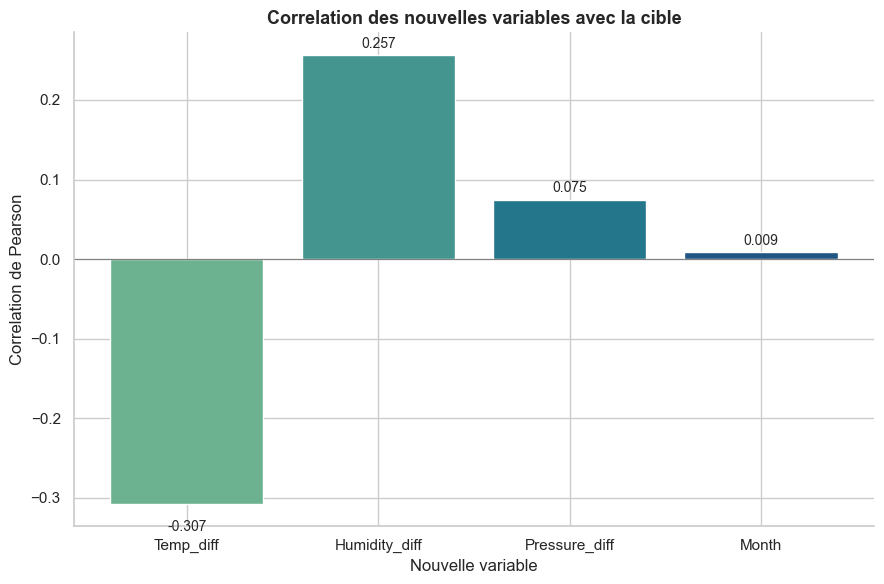

In [16]:
# CELL 14: Correlation des nouvelles variables numeriques avec la cible

import seaborn as sns

# Cible numerique temporaire sur le jeu d'entrainement uniquement
y_train_bin = (y_train == 'Yes').astype(int)

# Correlation de Pearson entre les nouvelles variables numeriques et la cible (sur X_train)
features_creees = ['Temp_diff', 'Humidity_diff', 'Pressure_diff', 'Month']
correlations = X_train[features_creees].corrwith(y_train_bin).sort_values(
    key=lambda s: s.abs(), ascending=False)

print("Correlation de Pearson des nouvelles variables avec la cible (X_train):")
print(correlations.round(4).to_string())

# Graphique
sns.set_theme(style="whitegrid", context="notebook")
couleurs = sns.color_palette("crest", len(correlations))

fig, ax = plt.subplots(figsize=(9, 6))
barres = ax.bar(correlations.index, correlations.values, color=couleurs)
# Annotation des valeurs sur les barres
for b in barres:
    h = b.get_height()
    ax.annotate(f"{h:.3f}",
                xy=(b.get_x() + b.get_width() / 2, h),
                xytext=(0, 3 if h >= 0 else -12), textcoords='offset points',
                ha='center', va='bottom' if h >= 0 else 'top', fontsize=10)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title("Correlation des nouvelles variables avec la cible", fontsize=13, fontweight='bold')
ax.set_xlabel("Nouvelle variable")
ax.set_ylabel("Correlation de Pearson")
sns.despine()
plt.tight_layout()
fig.savefig('../figures/etape2_05_correlation_features_creees.png', dpi=150, bbox_inches='tight')
print("\nFigure sauvegardee: figures/etape2_05_correlation_features_creees.png")
plt.show()

In [17]:
# CELL 15: Encodage des variables categorielles

# 1) Cible binaire (No -> 0, Yes -> 1)
y_train_enc = (y_train == 'Yes').astype(int)
y_test_enc = (y_test == 'Yes').astype(int)

# 2) Variable binaire RainToday : No -> 0, Yes -> 1
X_train['RainToday'] = X_train['RainToday'].map({'No': 0, 'Yes': 1})
X_test['RainToday'] = X_test['RainToday'].map({'No': 0, 'Yes': 1})

# 3) Encodage par la cible (target encoding) pour Location, ajuste sur X_train uniquement
loc_rate = y_train_enc.groupby(X_train['Location']).mean()
taux_global = y_train_enc.mean()

X_train['Location_encoded'] = X_train['Location'].map(loc_rate)
X_test['Location_encoded'] = X_test['Location'].map(loc_rate)

# Localites presentes dans X_test mais absentes de X_train : remplacees par le taux global d'entrainement
nb_non_vues = X_test['Location_encoded'].isnull().sum()
if nb_non_vues > 0:
    print(f"Attention : {nb_non_vues} ligne(s) de X_test avec une Location non vue en entrainement, "
          f"remplacee(s) par le taux global ({taux_global:.4f}).")
    X_test['Location_encoded'] = X_test['Location_encoded'].fillna(taux_global)
else:
    print("Aucune localite inconnue dans X_test (toutes vues en entrainement).")

# Suppression de la colonne Location d'origine
X_train = X_train.drop(columns=['Location'])
X_test = X_test.drop(columns=['Location'])

# 4) Suppression de Date (information desormais capturee par Month et Season)
X_train = X_train.drop(columns=['Date'])
X_test = X_test.drop(columns=['Date'])

# 5) One-hot (N-1) pour les categorielles a faible cardinalite
#    dtype=int pour des colonnes 0/1 homogenes (evite un melange bool/int lors du reindex)
cols_onehot = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'Season']
X_train = pd.get_dummies(X_train, columns=cols_onehot, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=cols_onehot, drop_first=True, dtype=int)
# Alignement de X_test sur les MEMES colonnes que X_train (colonnes absentes remplies par 0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Verification finale
print(f"\nDimensions finales X_train: {X_train.shape}")
print(f"Dimensions finales X_test:  {X_test.shape}")
print(f"Colonnes identiques entre X_train et X_test: {list(X_train.columns) == list(X_test.columns)}")

Aucune localite inconnue dans X_test (toutes vues en entrainement).



Dimensions finales X_train: (113754, 66)
Dimensions finales X_test:  (28439, 66)
Colonnes identiques entre X_train et X_test: True


Figure sauvegardee: figures/etape2_06_location_target_encoding.png


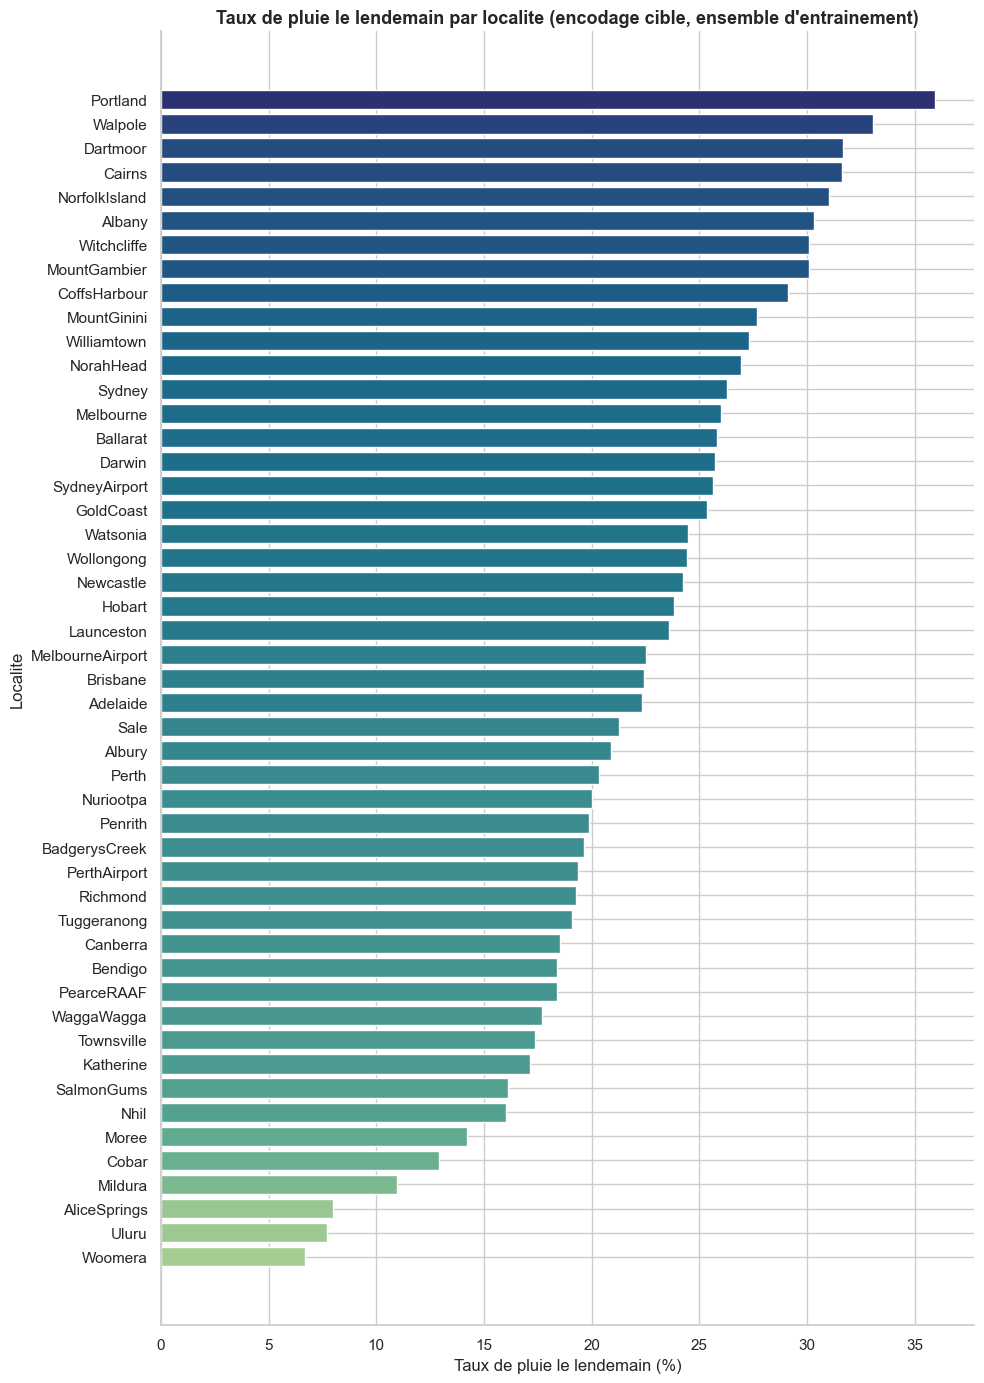


Top 5 localites les plus pluvieuses (taux %):
Location
Portland         35.96
Walpole          33.07
Dartmoor         31.66
Cairns           31.63
NorfolkIsland    31.03

Top 5 localites les plus seches (taux %):
Location
Cobar           12.91
Mildura         10.96
AliceSprings     8.01
Uluru            7.71
Woomera          6.70


In [18]:
# CELL 16: Visualisation de l'encodage de Location (taux de pluie par localite)

import seaborn as sns

# Reutilisation du mapping loc_rate calcule sur X_train en CELL 15 (aucun recalcul, donnees d'entrainement)
# Expression en pourcentage, trie du plus pluvieux au plus sec
loc_rate_pct = (loc_rate * 100).sort_values(ascending=False)

# Style
sns.set_theme(style="whitegrid", context="notebook")

# Couleurs : gradient sequentiel crest mappe sur le taux (fonce = plus pluvieux, clair = plus sec)
cmap = sns.color_palette("crest", as_cmap=True)
norm = plt.Normalize(loc_rate_pct.min(), loc_rate_pct.max())

# Trace : on inverse l'ordre pour afficher le plus pluvieux en haut du graphique
donnees = loc_rate_pct.iloc[::-1]
couleurs = cmap(norm(donnees.values))

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(donnees.index, donnees.values, color=couleurs)
ax.set_title("Taux de pluie le lendemain par localite (encodage cible, ensemble d'entrainement)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Taux de pluie le lendemain (%)")
ax.set_ylabel("Localite")
sns.despine()
plt.tight_layout()
fig.savefig('../figures/etape2_06_location_target_encoding.png', dpi=150, bbox_inches='tight')
print("Figure sauvegardee: figures/etape2_06_location_target_encoding.png")
plt.show()

# Top 5 (plus pluvieuses) et bottom 5 (plus seches)
print("\nTop 5 localites les plus pluvieuses (taux %):")
print(loc_rate_pct.head(5).round(2).to_string())
print("\nTop 5 localites les plus seches (taux %):")
print(loc_rate_pct.tail(5).round(2).to_string())

Correlation avec la cible (X_train) : Pearson vs Spearman
        Variable  Pearson  Spearman   Ecart  Gain_non_lineaire
     Humidity3pm   0.4388    0.4224 -0.0165            -0.0165
       Temp_diff  -0.3074   -0.3236 -0.0162             0.0162
        Rainfall   0.2319    0.3224  0.0905             0.0905
     Humidity9am   0.2543    0.2639  0.0097             0.0097
   Humidity_diff   0.2568    0.2496 -0.0072            -0.0072
     Pressure9am  -0.2341   -0.2201  0.0140            -0.0140
   WindGustSpeed   0.2234    0.2021 -0.0213            -0.0213
     Pressure3pm  -0.2150   -0.2012  0.0139            -0.0139
         Temp3pm  -0.1912   -0.1917 -0.0005             0.0005
         MaxTemp  -0.1599   -0.1599 -0.0001             0.0001
Location_encoded   0.1553    0.1508 -0.0045            -0.0045
    WindSpeed9am   0.0920    0.0820 -0.0100            -0.0100
   Pressure_diff   0.0748    0.0775  0.0026             0.0026
    WindSpeed3pm   0.0864    0.0753 -0.0112            -0.01


Figure sauvegardee: figures/etape2_07_pearson_vs_spearman.png


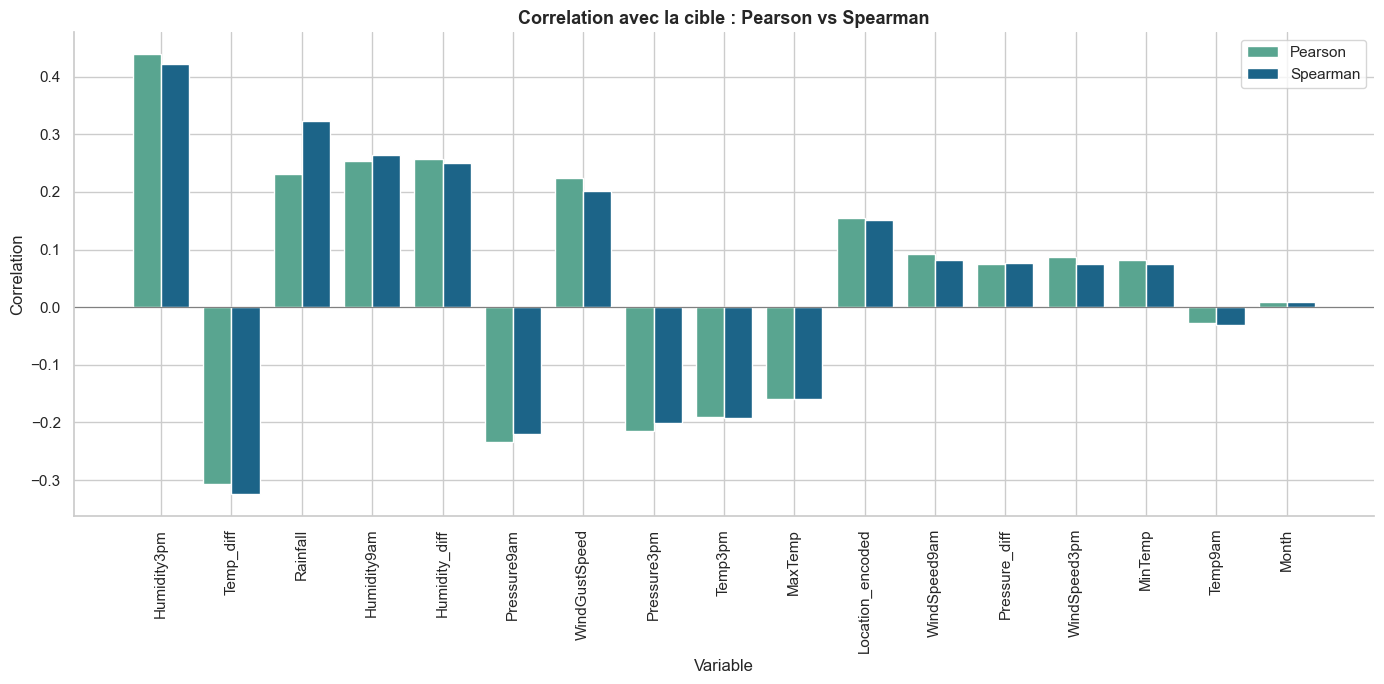

In [19]:
# CELL 17: Correlation de Spearman des variables numeriques avec la cible

from scipy.stats import pearsonr, spearmanr
import seaborn as sns

# Variables numeriques a tester (originales + creees), mesure sur X_train + y_train_enc
variables_num = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
                 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
                 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm',
                 'Temp_diff', 'Humidity_diff', 'Pressure_diff', 'Month', 'Location_encoded']

lignes = []
for col in variables_num:
    p = pearsonr(X_train[col], y_train_enc)[0]
    s = spearmanr(X_train[col], y_train_enc)[0]
    lignes.append({
        'Variable': col,
        'Pearson': round(p, 4),
        'Spearman': round(s, 4),
        'Ecart': round(s - p, 4),                 # difference signee Spearman - Pearson
        'Gain_non_lineaire': round(abs(s) - abs(p), 4)  # gain en amplitude de Spearman sur Pearson
    })

table_corr = pd.DataFrame(lignes)
# Tri par |Spearman| decroissant
table_corr = table_corr.reindex(
    table_corr['Spearman'].abs().sort_values(ascending=False).index).reset_index(drop=True)

print("Correlation avec la cible (X_train) : Pearson vs Spearman")
print(table_corr.to_string(index=False))

# Mise en evidence : variables ou |Spearman| depasse nettement |Pearson| (signal non lineaire manque par Pearson)
seuil = 0.05
non_lineaires = table_corr[table_corr['Gain_non_lineaire'] >= seuil]
print(f"\nSignal non lineaire (|Spearman| - |Pearson| >= {seuil}) :")
if len(non_lineaires) > 0:
    for _, r in non_lineaires.iterrows():
        print(f"  - {r['Variable']}: Pearson={r['Pearson']}, Spearman={r['Spearman']} (gain {r['Gain_non_lineaire']})")
else:
    print("  Aucune variable au-dessus du seuil.")

ligne_month = table_corr[table_corr['Variable'] == 'Month'].iloc[0]
print(f"Cas de Month : Pearson={ligne_month['Pearson']}, Spearman={ligne_month['Spearman']} "
      f"(les deux quasi nuls : ni Pearson ni Spearman ne captent Month, car la saisonnalite "
      f"est non monotone. Le signal saisonnier eventuel est porte par Season, pas par ces coefficients).")

# Graphique groupe Pearson vs Spearman
sns.set_theme(style="whitegrid", context="notebook")
couleurs = [sns.color_palette("crest")[1], sns.color_palette("crest")[4]]

ordre = table_corr['Variable'].tolist()
x = np.arange(len(ordre))
largeur = 0.4

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - largeur / 2, table_corr['Pearson'], largeur, label='Pearson', color=couleurs[0])
ax.bar(x + largeur / 2, table_corr['Spearman'], largeur, label='Spearman', color=couleurs[1])
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title("Correlation avec la cible : Pearson vs Spearman", fontsize=13, fontweight='bold')
ax.set_xlabel("Variable")
ax.set_ylabel("Correlation")
ax.set_xticks(x)
ax.set_xticklabels(ordre, rotation=90)
ax.legend()
sns.despine()
plt.tight_layout()
fig.savefig('../figures/etape2_07_pearson_vs_spearman.png', dpi=150, bbox_inches='tight')
print("\nFigure sauvegardee: figures/etape2_07_pearson_vs_spearman.png")
plt.show()

In [20]:
# CELL 18: Test de normalite des variables numeriques (Jarque-Bera) sur X_train

from scipy.stats import jarque_bera

# Variables numeriques continues (on exclut Month, Location_encoded et les colonnes one-hot/binaires)
variables_continues = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
                       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                       'Temp9am', 'Temp3pm', 'Temp_diff', 'Humidity_diff', 'Pressure_diff']

# Principe : a N eleve (113 754 obs), la p-valeur de tout test de normalite est quasi nulle et rejette
# la normalite meme pour de faibles ecarts. On interprete donc la STATISTIQUE JB (plus elle est faible,
# plus la distribution est proche de la normale) et les QQ-plots, et non la p-valeur en seuil binaire.
lignes = []
for col in variables_continues:
    jb_stat, jb_p = jarque_bera(X_train[col])
    lignes.append({
        'Variable': col,
        'JB_stat': round(jb_stat, 1),
        'skewness': round(X_train[col].skew(), 3),
        'p_valeur_non_decisive': jb_p  # affichee mais NON utilisee comme critere de decision
    })

table_jb = pd.DataFrame(lignes).sort_values('JB_stat', ascending=True).reset_index(drop=True)
# Affichage de la p-valeur en notation scientifique, marquee comme non decisive
table_jb['p_valeur_non_decisive'] = table_jb['p_valeur_non_decisive'].apply(lambda x: f"{x:.2e}")

print("Test de normalite Jarque-Bera (X_train), trie par JB_stat croissant (plus proche de la normale en haut):")
print(table_jb.to_string(index=False))
print("\nNote : la p-valeur est affichee mais NON decisive (rejet systematique a N eleve). "
      "On se fie a JB_stat et aux QQ-plots.")

Test de normalite Jarque-Bera (X_train), trie par JB_stat croissant (plus proche de la normale en haut):
     Variable     JB_stat  skewness p_valeur_non_decisive
      Temp9am       678.3     0.092             5.03e-148
  Humidity3pm       975.0     0.034             1.93e-212
      MinTemp      1100.7     0.024             9.58e-240
      Temp3pm      1124.2     0.240             7.64e-245
      MaxTemp      1176.4     0.222             3.45e-256
  Pressure3pm      1190.0    -0.052             3.87e-259
Humidity_diff      1310.7     0.088             2.45e-285
  Pressure9am      1956.6    -0.103              0.00e+00
    Temp_diff      4201.3     0.074              0.00e+00
  Humidity9am      4594.1    -0.492              0.00e+00
 WindSpeed3pm     10686.6     0.629              0.00e+00
 WindSpeed9am     18652.8     0.771              0.00e+00
WindGustSpeed     30365.7     0.920              0.00e+00
Pressure_diff     64640.9     0.639              0.00e+00
     Rainfall 176027925.1

Figure sauvegardee: figures/etape2_08_qqplots_normalite.png


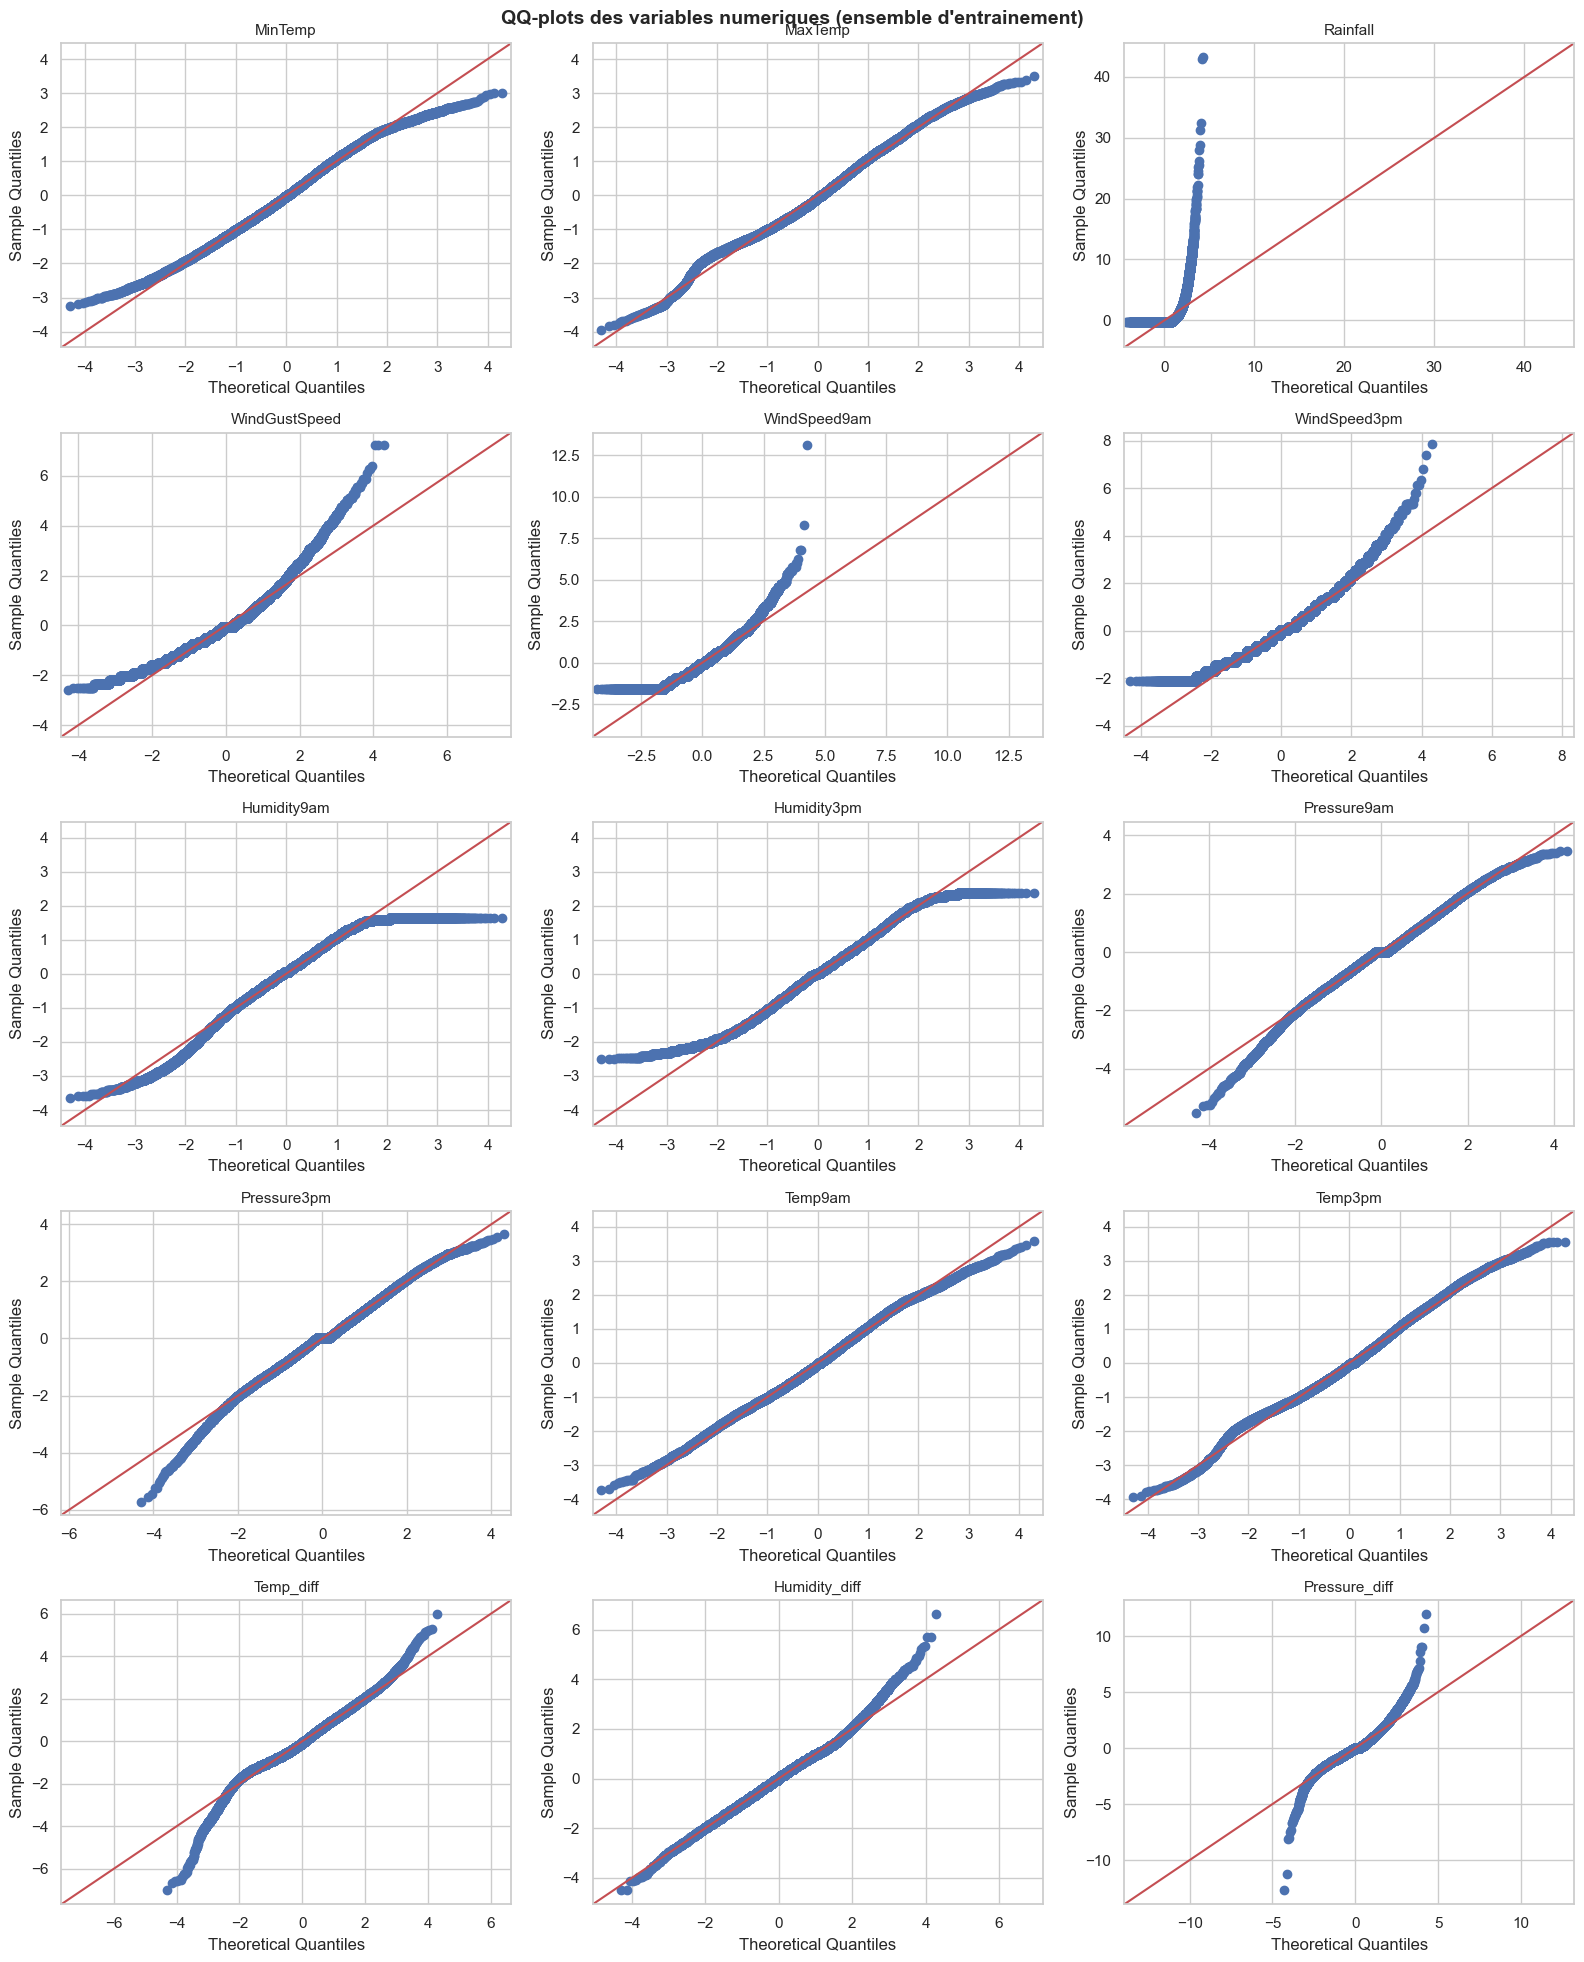

In [21]:
# CELL 19: QQ-plots des variables numeriques (X_train)

import statsmodels.api as sm
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# Un QQ-plot par variable continue (fit=True : ajustement loi normale, line='45' : reference y=x)
n = len(variables_continues)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.ravel()

for i, col in enumerate(variables_continues):
    sm.qqplot(X_train[col], line='45', fit=True, ax=axes[i])
    axes[i].set_title(col, fontsize=11)

# Masquer les sous-graphiques vides eventuels
for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("QQ-plots des variables numeriques (ensemble d'entrainement)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig('../figures/etape2_08_qqplots_normalite.png', dpi=150, bbox_inches='tight')
print("Figure sauvegardee: figures/etape2_08_qqplots_normalite.png")
plt.show()

In [22]:
# CELL 20: Mise a l'echelle (StandardScaler et RobustScaler, ajustes sur X_train)

from sklearn.preprocessing import StandardScaler, RobustScaler

# Colonnes quasi-normales : StandardScaler (centre-reduit, moyenne 0 / ecart-type 1)
standard_cols = ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm', 'Humidity3pm',
                 'Pressure9am', 'Pressure3pm', 'Temp_diff', 'Humidity_diff', 'Location_encoded']
# Colonnes asymetriques / avec valeurs extremes : RobustScaler (mediane + IQR, robuste aux outliers)
robust_cols = ['Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Pressure_diff']

# Ajustement sur X_train UNIQUEMENT, puis application a X_train ET X_test (regle anti-fuite)
scaler_standard = StandardScaler()
X_train[standard_cols] = scaler_standard.fit_transform(X_train[standard_cols])
X_test[standard_cols] = scaler_standard.transform(X_test[standard_cols])

scaler_robust = RobustScaler()
X_train[robust_cols] = scaler_robust.fit_transform(X_train[robust_cols])
X_test[robust_cols] = scaler_robust.transform(X_test[robust_cols])

# Month, RainToday et les colonnes one-hot ne sont PAS mis a l'echelle (deja 0/1 ou entier discret)

# Verification : moyenne ~0 pour les colonnes standardisees, mediane ~0 pour les colonnes robustes (X_train)
print("Moyenne apres StandardScaler (X_train, doit etre ~0):")
print(X_train[standard_cols].mean().round(6).to_string())
print("\nMediane apres RobustScaler (X_train, doit etre ~0):")
print(X_train[robust_cols].median().round(6).to_string())

Moyenne apres StandardScaler (X_train, doit etre ~0):
MinTemp            -0.0
MaxTemp             0.0
Temp9am             0.0
Temp3pm            -0.0
Humidity3pm         0.0
Pressure9am         0.0
Pressure3pm         0.0
Temp_diff           0.0
Humidity_diff       0.0
Location_encoded   -0.0

Mediane apres RobustScaler (X_train, doit etre ~0):
Rainfall         0.0
WindGustSpeed    0.0
WindSpeed9am     0.0
WindSpeed3pm     0.0
Humidity9am      0.0
Pressure_diff    0.0


In [23]:
# CELL 21: Sauvegarde des jeux de donnees pretraites

import os

# Creation du dossier de sortie si necessaire
dossier_sortie = '../data/output'
os.makedirs(dossier_sortie, exist_ok=True)

# Sauvegarde en CSV (sans l'index) : features et cibles, train et test
fichiers = {
    'X_train_prep.csv': X_train,
    'X_test_prep.csv': X_test,
    'y_train.csv': y_train_enc,
    'y_test.csv': y_test_enc,
}

for nom, objet in fichiers.items():
    chemin = os.path.join(dossier_sortie, nom)
    objet.to_csv(chemin, index=False)
    print(f"Ecrit : data/output/{nom} | dimensions : {objet.shape}")

Ecrit : data/output/X_train_prep.csv | dimensions : (113754, 66)


Ecrit : data/output/X_test_prep.csv | dimensions : (28439, 66)
Ecrit : data/output/y_train.csv | dimensions : (113754,)
Ecrit : data/output/y_test.csv | dimensions : (28439,)
